In [3]:
%pip install -q numpy scipy matplotlib lightkurve astroquery wotan transitleastsquares xgboost scikit-learn torch tqdm joblib pandas

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [4]:
import os
import warnings
import logging
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from typing import Optional, Dict, Tuple, List

import numpy as np
import scipy.stats as stats
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})


import lightkurve as lk
from lightkurve import TessTargetPixelFile

from astroquery.gaia import Gaia
from astroquery.mast import Catalogs
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table

from wotan import flatten, slide_clip

from transitleastsquares import transitleastsquares, cleaned_array
from transitleastsquares import catalog_info  # fetches stellar params from TIC

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

from tqdm.auto import tqdm
from joblib import Memory

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('ExoPipeline')

CACHE_DIR = Path('./pipeline_cache')
CACHE_DIR.mkdir(exist_ok=True)
memory = Memory(location=str(CACHE_DIR), verbose=0)

# ── Physical constants ────────────────────────────────────────────────────────
R_SUN_CM    = 6.957e10    # cm
R_JUP_CM    = 7.1492e9   # cm
R_EARTH_CM  = 6.371e8    # cm
R_JUP_R_SUN = R_JUP_CM / R_SUN_CM  # ≈ 0.1027

print('✅ All imports successful.')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


"ltr" dir="ltr" lang="en-GB">

Archive down for maintenance
"X-UA-Compatible" content="IE=edge" />

"UTF-8" />

Archive down for maintenance
"initial-scale=1.0, width=device-width" name="viewport" />

"Cache-Control" content="no-cache, no-store, must-revalidate">

"Pragma" content="no-cache">

"Expires" content="0">

"refresh" content="60" /> -->

"icon"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/favicon.ico" />

Archive down for maintenance
"apple-touch-icon-precomposed"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-precomposed.png" />

Archive down for maintenance
Archive down for maintenance
"apple-touch-icon-precomposed" sizes="72x72"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-72x72-precomposed.png" />

Archive down for maintenance
"apple-touch-icon-precomposed" sizes="76x76"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-76x76-precomposed.png" />

Archive down for maintenance
"apple-tou

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
@dataclass
class PipelineConfig:
    tic_id: str = 'TIC 260647166'   # ← Change this to your target

    # ── TESS download ─────────────────────────────────────────────────────────
    cadence: str = 'long'           # 'long' = 30-min FFI, 'short' = 2-min
    author: str = 'SPOC'            # 'SPOC' | 'TESS-SPOC' | 'QLP'
    max_gap_days: float = 0.5       # stitch gap threshold

    # ── Quality filtering ─────────────────────────────────────────────────────
    quality_bitmask: str = 'hardest'  # 'default' | 'hard' | 'hardest'
    sigma_clip_sigma: float = 5.0
    sigma_clip_maxiters: int = 5

    # ── Detrending ────────────────────────────────────────────────────────────
    wotan_window: float = 0.5         # days — biweight filter window
    wotan_method: str = 'biweight'    # 'biweight' | 'lowess' | 'huber'
    mask_transit_during_detrend: bool = True  # CRITICAL: prevents self-subtraction

    # ── LSTM-AE ───────────────────────────────────────────────────────────────
    ae_window: int = 128              # samples per window
    ae_hidden: int = 64
    ae_latent: int = 16
    ae_epochs: int = 30
    ae_lr: float = 1e-3
    ae_batch: int = 64
    ae_anomaly_percentile: float = 95.0  # flag top X% reconstruction error

    # ── BLS pre-scan (gates TLS) ──────────────────────────────────────────────
    bls_min_period: float = 0.5       # days
    bls_max_period: float = 27.0
    bls_sde_threshold: float = 6.0    # skip TLS if BLS SDE < this

    # ── TLS ───────────────────────────────────────────────────────────────────
    tls_min_period: float = 0.5
    tls_max_period: float = 27.0
    tls_sde_threshold: float = 7.0    # minimum SDE to call a detection
    tls_oversampling: int = 5         # frequency grid oversampling
    tls_duration_grid_step: float = 1.05

    # ── 1D-CNN ────────────────────────────────────────────────────────────────
    cnn_phase_bins: int = 128         # phase-folded bins fed to CNN
    cnn_channels: List[int] = field(default_factory=lambda: [32, 64, 128])
    cnn_latent_dim: int = 64

    # ── Vetting thresholds ────────────────────────────────────────────────────
    max_planet_radius_rjup: float = 2.0   # > this → eclipsing binary
    centroid_shift_threshold_px: float = 0.3  # pixels
    secondary_eclipse_threshold: float = 0.5  # depth ratio secondary/primary

    # ── Ensemble ──────────────────────────────────────────────────────────────
    ensemble_weights: Dict[str, float] = field(
        default_factory=lambda: {'cnn': 0.40, 'xgb': 0.35, 'rf': 0.25}
    )
    high_confidence_threshold: float = 0.85
    weak_signal_threshold: float = 0.50

    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    random_seed: int = 42
    n_jobs: int = -1                  # parallel workers for sklearn


cfg = PipelineConfig()
torch.manual_seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
print(f'Config ready | device={cfg.device} | target={cfg.tic_id}')

Config ready | device=cpu | target=TIC 260647166


In [6]:
def fetch_tess_data(tic_id: str, cfg: PipelineConfig):
    """
    Downloads all available TESS sectors for a given TIC ID.
    Returns:
        lc_collection : LightCurveCollection  (individual sectors)
        tpf_collection: TargetPixelFileCollection
    """
    logger.info(f'Searching MAST for {tic_id} ...')

    # ── Light curves ─────────────────────────────────────────────────────────
    search_lc = lk.search_lightcurve(
        tic_id,
        mission='TESS',
        cadence=cfg.cadence,
        author=cfg.author,
    )
    if len(search_lc) == 0:
        # Fallback to QLP if SPOC not available
        logger.warning('SPOC not found — falling back to QLP')
        search_lc = lk.search_lightcurve(tic_id, mission='TESS', cadence='long', author='QLP')

    logger.info(f'Found {len(search_lc)} sector(s)')
    lc_collection = search_lc.download_all(
        quality_bitmask=cfg.quality_bitmask,
        cache=True,
    )

    # ── Target Pixel Files (needed for centroid analysis) ─────────────────────
    search_tpf = lk.search_targetpixelfile(
        tic_id,
        mission='TESS',
        cadence=cfg.cadence,
        author=cfg.author,
    )
    tpf_collection = search_tpf.download_all(quality_bitmask=cfg.quality_bitmask, cache=True)

    return lc_collection, tpf_collection


# ─────────────────────────────────────────────────────────────────────────────
# Phase 1B: Gaia DR3 query (runs in parallel thread)
# ─────────────────────────────────────────────────────────────────────────────

@memory.cache
def fetch_gaia_params(tic_id: str) -> Dict:
    """
    Queries Gaia DR3 for the stellar parameters of the target.
    Falls back to TIC catalog values if Gaia match is ambiguous.
    Returns dict with keys: radius_sun, teff_k, parallax_mas, luminosity_lsun
    """
    logger.info('Querying Gaia DR3 ...')

    # First get sky coordinates from TIC
    tic_num = tic_id.replace('TIC ', '').strip()
    tic_result = Catalogs.query_criteria(
        catalog='TIC',
        ID=tic_num,
        objType='STAR',
    )

    ra  = float(tic_result['ra'][0])
    dec = float(tic_result['dec'][0])

    coord = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

    # Gaia DR3 cone search (1 arcsec radius)
    Gaia.ROW_LIMIT = 5
    gaia_query = f"""
        SELECT TOP 5
            s.source_id, s.ra, s.dec, s.parallax, s.parallax_error,
            p.teff_gspphot, p.teff_gspphot_lower, p.teff_gspphot_upper,
            p.radius_gspphot, p.radius_gspphot_lower, p.radius_gspphot_upper,
            p.lum_flame, p.lum_flame_lower, p.lum_flame_upper,
            s.phot_g_mean_mag, s.ruwe,
            DISTANCE(POINT('ICRS', s.ra, s.dec), POINT('ICRS', {ra}, {dec})) AS dist
        FROM gaiadr3.astrophysical_parameters AS p
        JOIN gaiadr3.gaia_source AS s ON p.source_id = s.source_id
        WHERE 1=CONTAINS(POINT('ICRS', s.ra, s.dec), CIRCLE('ICRS', {ra}, {dec}, 0.0003))
        ORDER BY dist ASC
    """
    job    = Gaia.launch_job(gaia_query)
    result = job.get_results()

    stellar = {}
    if len(result) > 0 and result['radius_gspphot'].mask[0] is False:
        row = result[0]
        stellar = {
            'radius_sun'      : float(row['radius_gspphot']),
            'radius_sun_err'  : float(row['radius_gspphot_upper']) - float(row['radius_gspphot_lower']),
            'teff_k'          : float(row['teff_gspphot']),
            'parallax_mas'    : float(row['parallax']),
            'parallax_err'    : float(row['parallax_error']),
            'luminosity_lsun' : float(row['lum_flame']) if not result['lum_flame'].mask[0] else np.nan,
            'ruwe'            : float(row['ruwe']),
            'source'          : 'GaiaDR3',
        }
        logger.info(f"Gaia DR3 match: R*={stellar['radius_sun']:.3f} Rsun, "
                    f"Teff={stellar['teff_k']:.0f}K, RUWE={stellar['ruwe']:.2f}")
    else:
        # Fallback: use TIC stellar params
        logger.warning('Gaia DR3 stellar params missing — using TIC fallback')
        stellar = {
            'radius_sun'   : float(tic_result['rad'][0]) if tic_result['rad'][0] else 1.0,
            'teff_k'       : float(tic_result['Teff'][0]) if tic_result['Teff'][0] else 5778.0,
            'parallax_mas' : np.nan,
            'source'       : 'TIC_fallback',
        }

    return stellar


# ─────────────────────────────────────────────────────────────────────────────
# PARALLEL INGESTION  ← both queries fire simultaneously
# ─────────────────────────────────────────────────────────────────────────────

def ingest_all(cfg: PipelineConfig):
    with ThreadPoolExecutor(max_workers=2) as ex:
        fut_tess = ex.submit(fetch_tess_data, cfg.tic_id, cfg)
        fut_gaia = ex.submit(fetch_gaia_params, cfg.tic_id)

        lc_collection, tpf_collection = fut_tess.result()
        stellar_params               = fut_gaia.result()

    logger.info(f'Ingestion complete | sectors={len(lc_collection)} | stellar={stellar_params["source"]}')
    return lc_collection, tpf_collection, stellar_params


lc_collection, tpf_collection, stellar_params = ingest_all(cfg)

2026-04-15 17:19:53,413 | INFO | Searching MAST for TIC 260647166 ...
2026-04-15 17:19:57,337 | WARNING | SPOC not found — falling back to QLP
2026-04-15 17:19:58,119 | INFO | Found 5 sector(s)
2026-04-15 17:19:58,143 | WARNING | Warning: 28% (341/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 17:19:58,143 | WARNING | Warning: 27% (324/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
2026-04-15 17:19:58,157 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 17:19:58,157 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
10% (338/3477) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 17:19:58,169 | INFO | 10% (338/3477) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
9% (325/3477) of th

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 1C: Multi-Sector Stitching with quality pre-filtering
# ─────────────────────────────────────────────────────────────────────────────

def quality_filter_sector(lc) -> Optional[object]:
    """
    Per-sector quality checks:
    - Drop sectors with > 40% cadences flagged
    - Drop sectors shorter than 5 days
    - Flag and remove momentum dump windows
    """
    if len(lc) < 240:   # < 5 days at 30-min cadence
        logger.warning(f'  Sector too short ({len(lc)} cadences) — skipping')
        return None

    # Sigma-clip obvious outliers before stitching
    lc = lc.remove_outliers(sigma=cfg.sigma_clip_sigma, maxiters=cfg.sigma_clip_maxiters)

    # Remove NaN flux
    lc = lc[np.isfinite(lc.flux.value)]

    # Normalize to median = 1
    lc = lc.normalize()

    return lc


def stitch_sectors(lc_collection, cfg: PipelineConfig):
    """
    Applies per-sector quality filtering then stitches all sectors.
    Uses corrector to equalise flux levels between sectors.
    """
    clean_lcs = []
    for i, lc in enumerate(lc_collection):
        logger.info(f'  Filtering sector {i+1}/{len(lc_collection)} ...')
        lc_clean = quality_filter_sector(lc)
        if lc_clean is not None:
            clean_lcs.append(lc_clean)

    if len(clean_lcs) == 0:
        raise RuntimeError('No sectors survived quality filtering!')

    logger.info(f'{len(clean_lcs)}/{len(lc_collection)} sectors passed quality filter')

    # Stitch with a corrector function that equalises sector medians
    stitched = lk.LightCurveCollection(clean_lcs).stitch(
        corrector_func=lambda x: x.normalize()
    )

    # Sort by time (avoid in-place sort behavior differences across lightkurve versions)
    sort_idx = np.argsort(stitched.time.value)
    stitched = stitched[sort_idx]

    logger.info(f'Stitched LC: {len(stitched)} cadences spanning '
                f'{stitched.time.value[-1] - stitched.time.value[0]:.1f} days')
    return stitched


lc_stitched = stitch_sectors(lc_collection, cfg)

# Extract arrays
time_raw = lc_stitched.time.value           # BJD
flux_raw = lc_stitched.flux.value           # normalized
flux_err = lc_stitched.flux_err.value       # photometric error
print(f'Raw LC shape: time={time_raw.shape}, flux={flux_raw.shape}')

2026-04-15 17:20:18,043 | INFO |   Filtering sector 1/5 ...
2026-04-15 17:20:18,058 | INFO |   Filtering sector 2/5 ...
2026-04-15 17:20:18,062 | INFO |   Filtering sector 3/5 ...
2026-04-15 17:20:18,070 | INFO |   Filtering sector 4/5 ...
2026-04-15 17:20:18,079 | INFO |   Filtering sector 5/5 ...
2026-04-15 17:20:18,086 | INFO | 5/5 sectors passed quality filter
2026-04-15 17:20:18,110 | INFO | Stitched LC: 22236 cadences spanning 2527.4 days


Raw LC shape: time=(22236,), flux=(22236,)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 2A: CBV (Cotrending Basis Vectors) correction
# ─────────────────────────────────────────────────────────────────────────────

def apply_cbv_correction(lc_collection, cfg):
    """
    Applies CBV correction per sector to remove spacecraft systematics.
    Returns a list of CBV-corrected light curves.
    """
    corrected = []
    for lc in lc_collection:
        try:
            cbv_corrector = lk.correctors.CBVCorrector(lc)
            lc_cbv = cbv_corrector.correct(
                cbv_type=['SingleScale', 'Spike'],
                cbv_indices='all',
                alpha=1e-4,           # L2 regularization
            )
            corrected.append(lc_cbv.normalize())
            logger.info(f'  CBV corrected sector (n_cbvs used: {cbv_corrector.coefficients.shape[0]})')
        except Exception as e:
            logger.warning(f'  CBV failed ({e}) — using raw sector')
            corrected.append(lc.normalize())
    return corrected


# Apply CBV per sector then re-stitch
cbv_corrected = apply_cbv_correction(lc_collection, cfg)
lc_cbv_stitched = lk.LightCurveCollection(cbv_corrected).stitch(
    corrector_func=lambda x: x.normalize()
)
sort_idx_cbv = np.argsort(lc_cbv_stitched.time.value)
lc_cbv_stitched = lc_cbv_stitched[sort_idx_cbv]

time_cbv = lc_cbv_stitched.time.value
flux_cbv = lc_cbv_stitched.flux.value
flux_err_cbv = lc_cbv_stitched.flux_err.value
print('CBV correction complete.')

2026-04-15 17:20:37,672 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 17:20:37,681 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 17:20:37,684 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 17:20:37,687 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 17:20:37,689 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector


CBV correction complete.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 2B: BLS pre-scan (fast period finder — gates expensive TLS)
#           Run BEFORE wotan so we know approximate transit times for masking
# ─────────────────────────────────────────────────────────────────────────────

def bls_prescan(time, flux, cfg: PipelineConfig):
    """
    Fast BLS scan to identify candidate periods.
    Returns (best_period, best_t0, depth, sde_bls)
    """
    from astropy.timeseries import BoxLeastSquares
    from astropy.time import Time

    logger.info('Running BLS pre-scan ...')
    bls = BoxLeastSquares(time * u.day, flux)

    periods = np.linspace(cfg.bls_min_period, cfg.bls_max_period, 5000)
    result = bls.power(periods * u.day, [0.01, 0.02, 0.05, 0.10] * u.day)

    best_idx    = np.argmax(result.power)
    best_period = result.period[best_idx].value
    best_t0     = result.transit_time[best_idx].value
    depth       = result.depth[best_idx]

    # Compute SDE-like score: (max_power - median) / std
    sde_bls = (result.power[best_idx] - np.median(result.power)) / np.std(result.power)

    logger.info(f'BLS: best_period={best_period:.4f}d, t0={best_t0:.4f}, '
                f'depth={depth:.5f}, SDE={sde_bls:.2f}')
    return best_period, best_t0, float(depth), float(sde_bls)


bls_period, bls_t0, bls_depth, bls_sde = bls_prescan(time_cbv, flux_cbv, cfg)

run_tls = bls_sde >= cfg.bls_sde_threshold
print(f'BLS SDE={bls_sde:.2f} | Gate threshold={cfg.bls_sde_threshold} | '
      f'Proceed to TLS: {run_tls}')

2026-04-15 17:21:06,942 | INFO | Running BLS pre-scan ...
2026-04-15 17:21:07,511 | INFO | BLS: best_period=6.5485d, t0=1573.0121, depth=0.00146, SDE=2.91


BLS SDE=2.91 | Gate threshold=6.0 | Proceed to TLS: False


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 2C: Wotan detrending WITH transit window masking
# CRITICAL: Masking prevents Wotan from flattening the transit dip itself
# ─────────────────────────────────────────────────────────────────────────────

def build_transit_mask(time, period, t0, duration_hours=3.0):
    """
    Creates a boolean mask (True = in-transit) using BLS best period.
    duration_hours: conservative estimate of transit duration.
    """
    duration_days = duration_hours / 24.0
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0   # center on 0
    mask = np.abs(phase) < (duration_days / period)
    return mask


def detrend_wotan(time, flux, transit_mask, cfg: PipelineConfig):
    """
    Applies wotan biweight detrending. Masked cadences are excluded from
    the trend fit, then interpolated over.
    """
    logger.info('Applying wotan detrending ...')

    # Flatten excluding transit mask
    flat_flux, trend = flatten(
        time,
        flux,
        window_length=cfg.wotan_window,
        method=cfg.wotan_method,
        mask=transit_mask,         # ← transit windows excluded from fit
        return_trend=True,
        break_tolerance=0.5,
        robust=True,
    )

    # Post-detrend sigma clip
    flat_flux = slide_clip(
        time, flat_flux,
        window_length=1.0,
        low=cfg.sigma_clip_sigma,
        high=cfg.sigma_clip_sigma,
        method='mad',
        center='median',
    )

    return flat_flux, trend


if run_tls:
    transit_mask = build_transit_mask(time_cbv, bls_period, bls_t0, duration_hours=4.0)
else:
    transit_mask = np.zeros(len(time_cbv), dtype=bool)  # no mask if BLS didn't trigger

flat_flux, stellar_trend = detrend_wotan(time_cbv, flux_cbv, transit_mask, cfg)

# Handle NaNs introduced by slide_clip
valid = np.isfinite(flat_flux)
time_det  = time_cbv[valid]
flux_det  = flat_flux[valid]
err_det   = flux_err_cbv[valid]
mask_det  = transit_mask[valid]

print(f'Detrended LC: {flux_det.shape[0]} valid cadences')

2026-04-15 17:21:10,690 | INFO | Applying wotan detrending ...


Detrended LC: 22235 valid cadences


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 2D: LSTM Autoencoder — anomaly scorer (The AI Edge)
# Trained on out-of-transit ("quiet") windows only.
# Transit dips appear as high reconstruction error.
# ─────────────────────────────────────────────────────────────────────────────

class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, latent_size=16):
        super().__init__()
        # Encoder
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.enc_fc = nn.Linear(hidden_size, latent_size)

        # Decoder
        self.dec_fc  = nn.Linear(latent_size, hidden_size)
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.out_fc = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        enc_out, _ = self.encoder(x)           # (batch, seq_len, hidden)
        latent      = self.enc_fc(enc_out)      # (batch, seq_len, latent)
        dec_in      = self.dec_fc(latent)       # (batch, seq_len, hidden)
        dec_out, _  = self.decoder(dec_in)      # (batch, seq_len, hidden)
        recon       = self.out_fc(dec_out)      # (batch, seq_len, 1)
        return recon


def make_windows(flux, window_size, step=None):
    """Slice flux into overlapping windows for AE training/inference."""
    if step is None:
        step = window_size // 4
    windows = []
    for i in range(0, len(flux) - window_size, step):
        windows.append(flux[i:i + window_size])
    return np.array(windows, dtype=np.float32)


def train_lstm_ae(flux_quiet, cfg: PipelineConfig) -> LSTMAutoEncoder:
    """
    Train LSTM-AE on quiet (out-of-transit) windows.
    """
    windows = make_windows(flux_quiet, cfg.ae_window)
    if len(windows) < 10:
        raise RuntimeError('Not enough quiet windows to train LSTM-AE')

    # Normalise windows to [0, 1]
    wmin, wmax = windows.min(), windows.max()
    windows_norm = (windows - wmin) / (wmax - wmin + 1e-8)

    X = torch.tensor(windows_norm[:, :, np.newaxis])  # (N, seq, 1)
    loader = DataLoader(
        TensorDataset(X),
        batch_size=cfg.ae_batch,
        shuffle=True,
        drop_last=True,
    )

    model = LSTMAutoEncoder(
        input_size=1,
        hidden_size=cfg.ae_hidden,
        latent_size=cfg.ae_latent,
    ).to(cfg.device)

    optimizer = optim.Adam(model.parameters(), lr=cfg.ae_lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.ae_epochs)
    criterion = nn.MSELoss()

    model.train()
    for epoch in tqdm(range(cfg.ae_epochs), desc='Training LSTM-AE'):
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(cfg.device)
            recon = model(batch)
            loss  = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

    logger.info(f'LSTM-AE training done | final loss={epoch_loss/len(loader):.6f}')
    return model


def compute_reconstruction_error(model, flux_all, cfg: PipelineConfig) -> np.ndarray:
    """
    Compute per-cadence reconstruction error using sliding window.
    """
    wmin, wmax = flux_all.min(), flux_all.max()
    flux_norm  = (flux_all - wmin) / (wmax - wmin + 1e-8)

    step    = cfg.ae_window // 4
    errors  = np.zeros(len(flux_norm))
    counts  = np.zeros(len(flux_norm))

    model.eval()
    with torch.no_grad():
        for i in range(0, len(flux_norm) - cfg.ae_window, step):
            window = flux_norm[i:i + cfg.ae_window]
            t_in   = torch.tensor(window[np.newaxis, :, np.newaxis], dtype=torch.float32).to(cfg.device)
            recon  = model(t_in).squeeze().cpu().numpy()
            err    = (window - recon) ** 2
            errors[i:i + cfg.ae_window] += err
            counts[i:i + cfg.ae_window] += 1

    counts[counts == 0] = 1
    return errors / counts


# Train on quiet windows (out-of-transit)
quiet_flux = flux_det[~mask_det]
lstm_ae    = train_lstm_ae(quiet_flux, cfg)

# Score full light curve
recon_error = compute_reconstruction_error(lstm_ae, flux_det, cfg)

# Anomaly mask: high reconstruction error = transit candidate
ae_threshold  = np.percentile(recon_error, cfg.ae_anomaly_percentile)
ae_anomaly    = recon_error > ae_threshold

print(f'LSTM-AE anomaly threshold: {ae_threshold:.6f} | '
      f'flagged cadences: {ae_anomaly.sum()} / {len(ae_anomaly)}')

Training LSTM-AE: 100%|██████████| 30/30 [00:22<00:00,  1.35it/s]
2026-04-15 17:21:40,289 | INFO | LSTM-AE training done | final loss=0.014451


LSTM-AE anomaly threshold: 0.056260 | flagged cadences: 1112 / 22235


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 3: Transit Least Squares (TLS)
# Only runs if BLS SDE gate passed
# ─────────────────────────────────────────────────────────────────────────────

tls_result = None

if run_tls:
    logger.info('Running TLS ...')

    # Use TIC stellar params to improve transit model
    try:
        ab, R_star, M_star = catalog_info(TIC_ID=int(cfg.tic_id.replace('TIC ', '')))
    except Exception:
        ab, R_star, M_star = [0.4, 0.3], 1.0, 1.0
        logger.warning('Could not fetch TIC catalog info — using solar defaults')

    # Override with Gaia if available
    if stellar_params.get('source') == 'GaiaDR3':
        R_star = stellar_params['radius_sun']

    t, f = cleaned_array(time_det, flux_det)

    model_tls = transitleastsquares(t, f)
    tls_result = model_tls.power(
        R_star=R_star,
        M_star=M_star,
        u=ab,
        period_min=cfg.tls_min_period,
        period_max=cfg.tls_max_period,
        oversampling_factor=cfg.tls_oversampling,
        duration_grid_step=cfg.tls_duration_grid_step,
        use_threads=4,
        show_progress_bar=True,
    )

    logger.info(
        f'TLS result: Period={tls_result.period:.5f} d | '
        f'SDE={tls_result.SDE:.2f} | '
        f'Depth={tls_result.depth:.5f} | '
        f'T0={tls_result.T0:.5f} | '
        f'Duration={tls_result.duration*24:.2f} h | '
        f'SNR={tls_result.snr:.2f}'
    )

    if tls_result.SDE < cfg.tls_sde_threshold:
        logger.warning(f'TLS SDE={tls_result.SDE:.2f} below threshold={cfg.tls_sde_threshold} — '
                       'marking as non-detection')
        run_tls = False
else:
    logger.info('BLS gate not passed — TLS skipped.')

2026-04-15 17:21:48,015 | INFO | BLS gate not passed — TLS skipped.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 4A: Phase-fold + 1D-CNN latent vector extractor
# ─────────────────────────────────────────────────────────────────────────────

class CNN1DEncoder(nn.Module):
    """
    1D-CNN that takes a phase-folded transit profile and returns
    a latent shape-signature vector.
    """
    def __init__(self, input_len=128, channels=(32, 64, 128), latent_dim=64):
        super().__init__()
        layers = []
        in_ch  = 1
        for out_ch in channels:
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Dropout(0.2),
            ]
            in_ch = out_ch
        self.conv_stack = nn.Sequential(*layers)

        # Compute flattened size dynamically
        dummy = torch.zeros(1, 1, input_len)
        flat_size = self.conv_stack(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):                         # x: (B, 1, L)
        z = self.conv_stack(x)                    # (B, C, L')
        z = z.view(z.size(0), -1)                 # (B, flat)
        return self.fc(z)                         # (B, latent_dim)


def phase_fold(time, flux, period, t0, n_bins=128):
    """
    Phase-fold light curve and bin into n_bins. Returns binned profile.
    """
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0

    # Sort by phase
    sort_idx = np.argsort(phase)
    phase_s, flux_s = phase[sort_idx], flux[sort_idx]

    # Bin
    bins   = np.linspace(-0.5, 0.5, n_bins + 1)
    binned = np.zeros(n_bins)
    for i in range(n_bins):
        mask_bin = (phase_s >= bins[i]) & (phase_s < bins[i+1])
        if mask_bin.sum() > 0:
            binned[i] = np.median(flux_s[mask_bin])
        else:
            binned[i] = 1.0

    # Normalise to [0, 1]
    binned = (binned - binned.min()) / (binned.max() - binned.min() + 1e-8)
    return binned.astype(np.float32)


def extract_cnn_vector(phase_profile, cfg: PipelineConfig) -> np.ndarray:
    """
    Pass phase-folded profile through 1D-CNN and return latent vector.
    """
    cnn = CNN1DEncoder(
        input_len=cfg.cnn_phase_bins,
        channels=tuple(cfg.cnn_channels),
        latent_dim=cfg.cnn_latent_dim,
    ).to(cfg.device)

    # NOTE: in production, load pre-trained weights here:
    # cnn.load_state_dict(torch.load('cnn_encoder.pth'))

    cnn.eval()
    with torch.no_grad():
        t_in = torch.tensor(phase_profile[np.newaxis, np.newaxis, :]).to(cfg.device)
        vec  = cnn(t_in).cpu().numpy().squeeze()
    return vec


if run_tls and tls_result is not None:
    phase_profile = phase_fold(
        time_det, flux_det,
        tls_result.period, tls_result.T0,
        n_bins=cfg.cnn_phase_bins,
    )
    cnn_vector = extract_cnn_vector(phase_profile, cfg)
    print(f'CNN latent vector: shape={cnn_vector.shape}')
else:
    cnn_vector    = np.zeros(cfg.cnn_latent_dim)
    phase_profile = np.ones(cfg.cnn_phase_bins, dtype=np.float32)

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 4B: Physical feature extraction
# ─────────────────────────────────────────────────────────────────────────────

def compute_planet_radius(depth, R_star_sun):
    """Rp = Rs * sqrt(depth) — returns in Jupiter radii."""
    R_p_sun = R_star_sun * np.sqrt(np.abs(depth))
    R_p_rjup = R_p_sun / R_JUP_R_SUN
    return R_p_rjup


def odd_even_mismatch(time, flux, period, t0, depth):
    """
    Compute the odd-even transit depth ratio.
    Ratio >> 1 indicates eclipsing binary (False Positive).
    """
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0

    in_transit = np.abs(phase) < 0.02
    transit_times = time[in_transit]

    if len(transit_times) < 5:
        return 0.0, 0.0, 0.0

    # Count which transit event each in-transit cadence belongs to
    n_transit = np.round((transit_times - t0) / period).astype(int)

    odd_depths, even_depths = [], []
    for n in np.unique(n_transit):
        mask_n = n_transit == n
        d_n = 1.0 - np.median(flux[in_transit][mask_n])
        if n % 2 == 0:
            even_depths.append(d_n)
        else:
            odd_depths.append(d_n)

    odd_mean  = np.mean(odd_depths)  if odd_depths  else 0.0
    even_mean = np.mean(even_depths) if even_depths else 0.0
    ratio = odd_mean / (even_mean + 1e-8)
    return odd_mean, even_mean, ratio


def secondary_eclipse_depth(time, flux, period, t0):
    """
    Check phase=0.5 for secondary eclipse (eclipsing binary indicator).
    Returns secondary eclipse depth (positive = dip detected).
    """
    phase = ((time - t0) % period) / period
    secondary_mask = np.abs(phase - 0.5) < 0.02
    if secondary_mask.sum() < 3:
        return 0.0
    sec_depth = 1.0 - np.median(flux[secondary_mask])
    return float(sec_depth)


def compute_snr(flux, transit_mask):
    """Simple SNR: transit depth / out-of-transit scatter."""
    if transit_mask.sum() == 0:
        return 0.0
    in_transit_flux  = flux[transit_mask]
    out_transit_flux = flux[~transit_mask]
    depth  = 1.0 - np.median(in_transit_flux)
    scatter = np.std(out_transit_flux)
    return float(depth / (scatter + 1e-10))


def extract_physical_features(time, flux, tls_result, stellar_params, cfg):
    """
    Compute all physical / statistical features for ML classifiers.
    Returns a feature dict.
    """
    if tls_result is None:
        return {k: 0.0 for k in [
            'period', 'depth', 'duration_h', 'sde', 'snr', 'r_planet_rjup',
            'odd_depth', 'even_depth', 'odd_even_ratio', 'secondary_depth',
            'n_transits', 'transit_count_quality',
            'rstar', 'teff', 'bls_sde', 'ae_anomaly_frac',
        ]}

    R_star = stellar_params.get('radius_sun', 1.0)
    depth  = float(tls_result.depth)

    R_p_rjup = compute_planet_radius(depth, R_star)

    transit_mask_tls = build_transit_mask(
        time, tls_result.period, tls_result.T0,
        duration_hours=tls_result.duration * 24,
    )
    snr = compute_snr(flux, transit_mask_tls)

    odd_d, even_d, oe_ratio = odd_even_mismatch(
        time, flux, tls_result.period, tls_result.T0, depth
    )
    sec_depth = secondary_eclipse_depth(time, flux, tls_result.period, tls_result.T0)

    # Transit count quality: fraction of expected transits actually observed
    baseline = time[-1] - time[0]
    n_expected = baseline / tls_result.period
    n_observed = len(tls_result.transit_times)
    tc_quality = n_observed / (n_expected + 1e-8)

    ae_anomaly_frac = ae_anomaly[transit_mask_tls].mean() if transit_mask_tls.sum() > 0 else 0.0

    feats = {
        'period'              : float(tls_result.period),
        'depth'               : depth,
        'duration_h'          : float(tls_result.duration) * 24,
        'sde'                 : float(tls_result.SDE),
        'snr'                 : snr,
        'r_planet_rjup'       : R_p_rjup,
        'odd_depth'           : odd_d,
        'even_depth'          : even_d,
        'odd_even_ratio'      : oe_ratio,
        'secondary_depth'     : sec_depth,
        'n_transits'          : n_observed,
        'transit_count_quality': tc_quality,
        'rstar'               : R_star,
        'teff'                : stellar_params.get('teff_k', 5778.0),
        'bls_sde'             : bls_sde,
        'ae_anomaly_frac'     : float(ae_anomaly_frac),
    }
    return feats


physical_feats = extract_physical_features(time_det, flux_det, tls_result, stellar_params, cfg)
print('Physical features:')
for k, v in physical_feats.items():
    print(f'  {k:<28} {v:.5g}')

Physical features:
  period                       0
  depth                        0
  duration_h                   0
  sde                          0
  snr                          0
  r_planet_rjup                0
  odd_depth                    0
  even_depth                   0
  odd_even_ratio               0
  secondary_depth              0
  n_transits                   0
  transit_count_quality        0
  rstar                        0
  teff                         0
  bls_sde                      0
  ae_anomaly_frac              0


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 5: Three hard-logic vetting tests
# A composite FP score [0, 1] is returned (0 = clean, 1 = certain FP)
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class VettingResult:
    passed_centroid   : bool    = True
    passed_radius     : bool    = True
    passed_secondary  : bool    = True
    passed_odd_even   : bool    = True
    centroid_shift_px : float   = 0.0
    planet_radius_rjup: float   = 0.0
    secondary_depth   : float   = 0.0
    odd_even_ratio    : float   = 1.0
    fp_score          : float   = 0.0   # 0=clean, 1=FP
    fp_reasons        : list    = field(default_factory=list)


def compute_centroid_shift(tpf_collection, tls_result, cfg) -> float:
    """
    Measures the shift of center-of-light in the TPF during transit.
    Returns shift in pixels. Large shift → background contamination.
    """
    if tpf_collection is None or tls_result is None:
        return 0.0

    shifts = []
    for tpf in tpf_collection:
        try:
            # Build in-transit mask
            t = tpf.time.value
            in_transit = build_transit_mask(
                t, tls_result.period, tls_result.T0,
                duration_hours=tls_result.duration * 24
            )
            out_transit = ~in_transit

            if in_transit.sum() < 3 or out_transit.sum() < 3:
                continue

            flux_tpf = tpf.flux.value  # shape (n_cadences, rows, cols)

            # Centroid: flux-weighted mean pixel position
            rows = np.arange(flux_tpf.shape[1])
            cols = np.arange(flux_tpf.shape[2])
            R, C = np.meshgrid(rows, cols, indexing='ij')

            def centroid(frames):
                f = np.nanmean(frames, axis=0)
                f = np.clip(f, 0, None)
                total = f.sum() + 1e-12
                cx = (f * C).sum() / total
                cy = (f * R).sum() / total
                return cx, cy

            cx_in,  cy_in  = centroid(flux_tpf[in_transit])
            cx_out, cy_out = centroid(flux_tpf[out_transit])

            shift = np.sqrt((cx_in - cx_out)**2 + (cy_in - cy_out)**2)
            shifts.append(shift)

        except Exception as e:
            logger.warning(f'Centroid analysis failed for sector: {e}')

    return float(np.median(shifts)) if shifts else 0.0


def vet_candidate(physical_feats, tpf_collection, tls_result, cfg) -> VettingResult:
    result   = VettingResult()
    fp_score = 0.0

    # ── Test 1: Centroid shift ────────────────────────────────────────────────
    shift_px = compute_centroid_shift(tpf_collection, tls_result, cfg)
    result.centroid_shift_px = shift_px
    if shift_px > cfg.centroid_shift_threshold_px:
        result.passed_centroid = False
        result.fp_reasons.append(f'Centroid shift {shift_px:.3f}px > {cfg.centroid_shift_threshold_px}px')
        fp_score += 0.40

    # ── Test 2: Planet radius limit ───────────────────────────────────────────
    R_p = physical_feats['r_planet_rjup']
    result.planet_radius_rjup = R_p
    if R_p > cfg.max_planet_radius_rjup:
        result.passed_radius = False
        result.fp_reasons.append(f'Rp={R_p:.3f} RJup > {cfg.max_planet_radius_rjup} RJup (likely EB)')
        fp_score += 0.40

    # ── Test 3: Secondary eclipse ─────────────────────────────────────────────
    sec_depth  = physical_feats['secondary_depth']
    prim_depth = physical_feats['depth']
    result.secondary_depth = sec_depth
    sec_ratio  = sec_depth / (prim_depth + 1e-10)
    if sec_ratio > cfg.secondary_eclipse_threshold:
        result.passed_secondary = False
        result.fp_reasons.append(f'Secondary eclipse ratio={sec_ratio:.3f} > {cfg.secondary_eclipse_threshold}')
        fp_score += 0.30

    # ── Test 4: Odd/Even depth mismatch ──────────────────────────────────────
    oe_ratio = physical_feats['odd_even_ratio']
    result.odd_even_ratio = oe_ratio
    if oe_ratio > 2.0 or oe_ratio < 0.5:
        result.passed_odd_even = False
        result.fp_reasons.append(f'Odd/Even ratio={oe_ratio:.3f} — depth inconsistency')
        fp_score += 0.20

    result.fp_score = min(fp_score, 1.0)
    return result


vet = vet_candidate(physical_feats, tpf_collection, tls_result, cfg)

print('\n═══ VETTING REPORT ═══')
print(f'  Centroid shift  : {vet.centroid_shift_px:.4f} px   → {"PASS" if vet.passed_centroid else "FAIL"}')
print(f'  Planet radius   : {vet.planet_radius_rjup:.4f} RJup → {"PASS" if vet.passed_radius   else "FAIL"}')
print(f'  Secondary eclipse: {vet.secondary_depth:.5f}    → {"PASS" if vet.passed_secondary else "FAIL"}')
print(f'  Odd/Even ratio  : {vet.odd_even_ratio:.4f}        → {"PASS" if vet.passed_odd_even else "FAIL"}')
print(f'  FP Score        : {vet.fp_score:.2f} (0=clean, 1=FP)')
if vet.fp_reasons:
    print('  FP Reasons:')
    for r in vet.fp_reasons:
        print(f'    ⚠️  {r}')
else:
    print('  ✅ No FP flags raised.')


═══ VETTING REPORT ═══
  Centroid shift  : 0.0000 px   → PASS
  Planet radius   : 0.0000 RJup → PASS
  Secondary eclipse: 0.00000    → PASS
  Odd/Even ratio  : 0.0000        → FAIL
  FP Score        : 0.20 (0=clean, 1=FP)
  FP Reasons:
    ⚠️  Odd/Even ratio=0.000 — depth inconsistency


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 6A: Feature vector assembly
# Combines: CNN latent vector + physical features + vetting scores
# ─────────────────────────────────────────────────────────────────────────────

def assemble_feature_vector(cnn_vec, physical_feats, vet: VettingResult) -> np.ndarray:
    """
    Concatenates all features into a single vector for tabular models.
    Physical + vetting features go to XGBoost/RF.
    CNN vector goes to CNN head (separate).
    """
    phys_vec = np.array([
        physical_feats['period'],
        physical_feats['depth'],
        physical_feats['duration_h'],
        physical_feats['sde'],
        physical_feats['snr'],
        physical_feats['r_planet_rjup'],
        physical_feats['odd_even_ratio'],
        physical_feats['secondary_depth'],
        physical_feats['n_transits'],
        physical_feats['transit_count_quality'],
        physical_feats['rstar'],
        physical_feats['teff'],
        physical_feats['bls_sde'],
        physical_feats['ae_anomaly_frac'],
        float(vet.centroid_shift_px),
        float(vet.fp_score),
        float(vet.passed_centroid),
        float(vet.passed_radius),
        float(vet.passed_secondary),
        float(vet.passed_odd_even),
    ], dtype=np.float32)

    full_vec = np.concatenate([cnn_vec.astype(np.float32), phys_vec])
    return full_vec, phys_vec


full_feature_vec, phys_feature_vec = assemble_feature_vector(cnn_vector, physical_feats, vet)
print(f'Full feature vector: {full_feature_vec.shape[0]} dims '
      f'({cnn_vector.shape[0]} CNN + {phys_feature_vec.shape[0]} physical)')

Full feature vector: 84 dims (64 CNN + 20 physical)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 6B: Ensemble model definitions
# In production: train these on a labeled dataset (e.g., DR25 TCEs)
# Here: we define the architectures and show how inference works
# ─────────────────────────────────────────────────────────────────────────────

class CNNClassifier(nn.Module):
    """Classification head on top of CNN latent vector."""
    def __init__(self, latent_dim=64, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def build_xgb_classifier(n_phys_features: int) -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=cfg.random_seed,
        n_jobs=cfg.n_jobs,
        tree_method='hist',    # fast histogram method
    )


def build_rf_classifier() -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=cfg.random_seed,
        n_jobs=cfg.n_jobs,
    )


# ── Calibrated classifiers (isotonic regression wraps each model) ─────────────
# This turns raw model scores into proper probabilities

xgb_model = CalibratedClassifierCV(
    build_xgb_classifier(len(phys_feature_vec)),
    method='isotonic',
    cv=3,
)

rf_model = CalibratedClassifierCV(
    build_rf_classifier(),
    method='isotonic',
    cv=3,
)

cnn_classifier = CNNClassifier(latent_dim=cfg.cnn_latent_dim).to(cfg.device)

print('Ensemble models built. Ready for training.')
print('NOTE: To train on real data, load the Kepler DR25 TCE catalog or TESS TOI catalog')
print('      and call xgb_model.fit(X_train, y_train), rf_model.fit(...), etc.')

Ensemble models built. Ready for training.
NOTE: To train on real data, load the Kepler DR25 TCE catalog or TESS TOI catalog
      and call xgb_model.fit(X_train, y_train), rf_model.fit(...), etc.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 6C: Training stub on real labeled data
# Replace X_train, y_train with your actual DR25/TOI dataset
# ─────────────────────────────────────────────────────────────────────────────

def train_ensemble_on_catalog(
    X_phys: np.ndarray,  # (N, n_phys_features)
    X_cnn:  np.ndarray,  # (N, cnn_latent_dim)
    y:      np.ndarray,  # (N,)  binary labels: 1=planet, 0=FP
    cfg: PipelineConfig,
):
    """
    Train XGBoost, RF, and CNN classifiers.
    Returns trained models.
    """
    from sklearn.model_selection import train_test_split

    X_tr_p, X_val_p, X_tr_c, X_val_c, y_tr, y_val = train_test_split(
        X_phys, X_cnn, y,
        test_size=0.15,
        stratify=y,
        random_state=cfg.random_seed,
    )

    scaler_p = StandardScaler().fit(X_tr_p)
    X_tr_p_s  = scaler_p.transform(X_tr_p)
    X_val_p_s = scaler_p.transform(X_val_p)

    # ── XGBoost ───────────────────────────────────────────────────────────────
    logger.info('Training XGBoost ...')
    xgb_clf = build_xgb_classifier(X_phys.shape[1])
    xgb_clf.fit(
        X_tr_p_s, y_tr,
        eval_set=[(X_val_p_s, y_val)],
        verbose=50,
    )
    xgb_cal = CalibratedClassifierCV(xgb_clf, method='isotonic', cv='prefit')
    xgb_cal.fit(X_val_p_s, y_val)

    # ── Random Forest ─────────────────────────────────────────────────────────
    logger.info('Training Random Forest ...')
    rf_clf = build_rf_classifier()
    rf_clf.fit(X_tr_p_s, y_tr)
    rf_cal = CalibratedClassifierCV(rf_clf, method='isotonic', cv='prefit')
    rf_cal.fit(X_val_p_s, y_val)

    # ── CNN classifier ────────────────────────────────────────────────────────
    logger.info('Training CNN classifier ...')
    cnn_clf = CNNClassifier(latent_dim=cfg.cnn_latent_dim).to(cfg.device)
    scaler_c = StandardScaler().fit(X_tr_c)
    X_tr_c_s  = scaler_c.transform(X_tr_c).astype(np.float32)
    X_val_c_s = scaler_c.transform(X_val_c).astype(np.float32)

    t_X = torch.tensor(X_tr_c_s).to(cfg.device)
    t_y = torch.tensor(y_tr).long().to(cfg.device)
    ds  = TensorDataset(t_X, t_y)
    dl  = DataLoader(ds, batch_size=32, shuffle=True)

    opt = optim.Adam(cnn_clf.parameters(), lr=1e-3)
    ce  = nn.CrossEntropyLoss()
    for ep in tqdm(range(50), desc='CNN training'):
        for xb, yb in dl:
            logits = cnn_clf(xb)
            loss   = ce(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()

    # ── Evaluation ────────────────────────────────────────────────────────────
    xgb_auc = roc_auc_score(y_val, xgb_cal.predict_proba(X_val_p_s)[:, 1])
    rf_auc  = roc_auc_score(y_val, rf_cal.predict_proba(X_val_p_s)[:, 1])

    cnn_clf.eval()
    with torch.no_grad():
        cnn_probs = torch.softmax(
            cnn_clf(torch.tensor(X_val_c_s).to(cfg.device)), dim=1
        )[:, 1].cpu().numpy()
    cnn_auc = roc_auc_score(y_val, cnn_probs)

    logger.info(f'Validation AUC | XGB={xgb_auc:.4f} | RF={rf_auc:.4f} | CNN={cnn_auc:.4f}')

    return {
        'xgb': xgb_cal, 'rf': rf_cal, 'cnn': cnn_clf,
        'scaler_p': scaler_p, 'scaler_c': scaler_c,
        'val_auc': {'xgb': xgb_auc, 'rf': rf_auc, 'cnn': cnn_auc},
    }


print('Training function defined. Call train_ensemble_on_catalog(X_phys, X_cnn, y, cfg) '
      'with your labeled catalog to train all models.')

Training function defined. Call train_ensemble_on_catalog(X_phys, X_cnn, y, cfg) with your labeled catalog to train all models.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Phase 6D: Consensus voting logic
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class PredictionResult:
    cnn_prob      : float = 0.0
    xgb_prob      : float = 0.0
    rf_prob       : float = 0.0
    ensemble_prob : float = 0.0
    fp_adjusted_prob: float = 0.0
    verdict       : str   = 'UNKNOWN'
    confidence    : str   = 'LOW'
    explanation   : str   = ''


def ensemble_predict(
    cnn_prob: float,
    xgb_prob: float,
    rf_prob:  float,
    vet:      VettingResult,
    cfg:      PipelineConfig,
) -> PredictionResult:
    """
    Weighted consensus with hard vetting override.
    """
    result = PredictionResult(cnn_prob=cnn_prob, xgb_prob=xgb_prob, rf_prob=rf_prob)

    w = cfg.ensemble_weights
    ensemble_prob = (
        w['cnn'] * cnn_prob +
        w['xgb'] * xgb_prob +
        w['rf']  * rf_prob
    )
    result.ensemble_prob = ensemble_prob

    # FP-adjusted probability: penalise by vetting FP score
    fp_adjusted = ensemble_prob * (1 - vet.fp_score)
    result.fp_adjusted_prob = float(np.clip(fp_adjusted, 0, 1))

    # ── Hard overrides from vetting ───────────────────────────────────────────
    if not vet.passed_radius:
        result.verdict     = 'FALSE_POSITIVE'
        result.confidence  = 'HIGH'
        result.explanation = ('Planet radius exceeds 2 RJup — this is an eclipsing binary, '
                              'not a planet candidate.')
        return result

    if not vet.passed_centroid:
        result.verdict     = 'FALSE_POSITIVE'
        result.confidence  = 'HIGH'
        result.explanation = ('Centroid shift detected during transit — signal originates '
                              'from a background eclipsing binary, not the target star.')
        return result

    if not vet.passed_secondary:
        result.verdict     = 'FALSE_POSITIVE'
        result.confidence  = 'MEDIUM'
        result.explanation = ('Secondary eclipse found at phase=0.5 — consistent with '
                              'an eclipsing binary system.')
        return result

    # ── Consensus voting rules ────────────────────────────────────────────────
    p = result.fp_adjusted_prob

    cnn_yes  = cnn_prob  >= 0.5
    xgb_yes  = xgb_prob  >= 0.5
    rf_yes   = rf_prob   >= 0.5
    all_agree_yes = cnn_yes and xgb_yes and rf_yes
    all_agree_no  = (not cnn_yes) and (not xgb_yes) and (not rf_yes)

    if all_agree_yes and p >= cfg.high_confidence_threshold:
        result.verdict     = 'PLANET_CANDIDATE'
        result.confidence  = 'HIGH'
        result.explanation = f'All three models agree: planet (p={p:.3f}). Vetting passed.'

    elif all_agree_yes:
        result.verdict     = 'PLANET_CANDIDATE'
        result.confidence  = 'MEDIUM'
        result.explanation = f'All models agree: planet, but FP-adjusted probability modest (p={p:.3f}).'

    elif cnn_yes and not xgb_yes:
        result.verdict     = 'LIKELY_NOISE'
        result.confidence  = 'MEDIUM'
        result.explanation = 'CNN detects a dip shape, but physical features (XGBoost) disagree. Likely instrumental noise.'

    elif xgb_yes and not cnn_yes:
        result.verdict     = 'WEAK_SIGNAL'
        result.confidence  = 'LOW'
        result.explanation = 'Physical features suggest a real transit, but CNN finds the shape unconvincing. Requires manual review.'

    elif all_agree_no:
        result.verdict     = 'NON_DETECTION'
        result.confidence  = 'HIGH'
        result.explanation = f'All models agree: no planet (p={p:.3f}).'

    else:
        result.verdict     = 'AMBIGUOUS'
        result.confidence  = 'LOW'
        result.explanation = 'Mixed model votes. Requires expert review.'

    return result


# ── Demo inference with random probabilities (replace with real model.predict) ─
# In production, load trained models and run:
#   xgb_prob = trained_models['xgb'].predict_proba(phys_vec_scaled)[0, 1]
#   rf_prob  = trained_models['rf'].predict_proba(phys_vec_scaled)[0, 1]
#   with torch.no_grad(): cnn_prob = softmax(cnn_clf(cnn_vec_tensor))[0, 1]

demo_cnn_prob = 0.82
demo_xgb_prob = 0.77
demo_rf_prob  = 0.71

prediction = ensemble_predict(demo_cnn_prob, demo_xgb_prob, demo_rf_prob, vet, cfg)

print('\n╔══════════════════════════════════════════╗')
print(f'║  VERDICT:     {prediction.verdict:<26} ║')
print(f'║  CONFIDENCE:  {prediction.confidence:<26} ║')
print(f'║  P(planet):   {prediction.fp_adjusted_prob:<26.4f} ║')
print('╚══════════════════════════════════════════╝')
print(f'\n  {prediction.explanation}')
print(f'\n  CNN={prediction.cnn_prob:.3f} | XGB={prediction.xgb_prob:.3f} | RF={prediction.rf_prob:.3f}')
print(f'  Ensemble={prediction.ensemble_prob:.3f} | FP-adjusted={prediction.fp_adjusted_prob:.3f}')


╔══════════════════════════════════════════╗
║  VERDICT:     PLANET_CANDIDATE           ║
║  CONFIDENCE:  MEDIUM                     ║
║  P(planet):   0.6200                     ║
╚══════════════════════════════════════════╝

  All models agree: planet, but FP-adjusted probability modest (p=0.620).

  CNN=0.820 | XGB=0.770 | RF=0.710
  Ensemble=0.775 | FP-adjusted=0.620


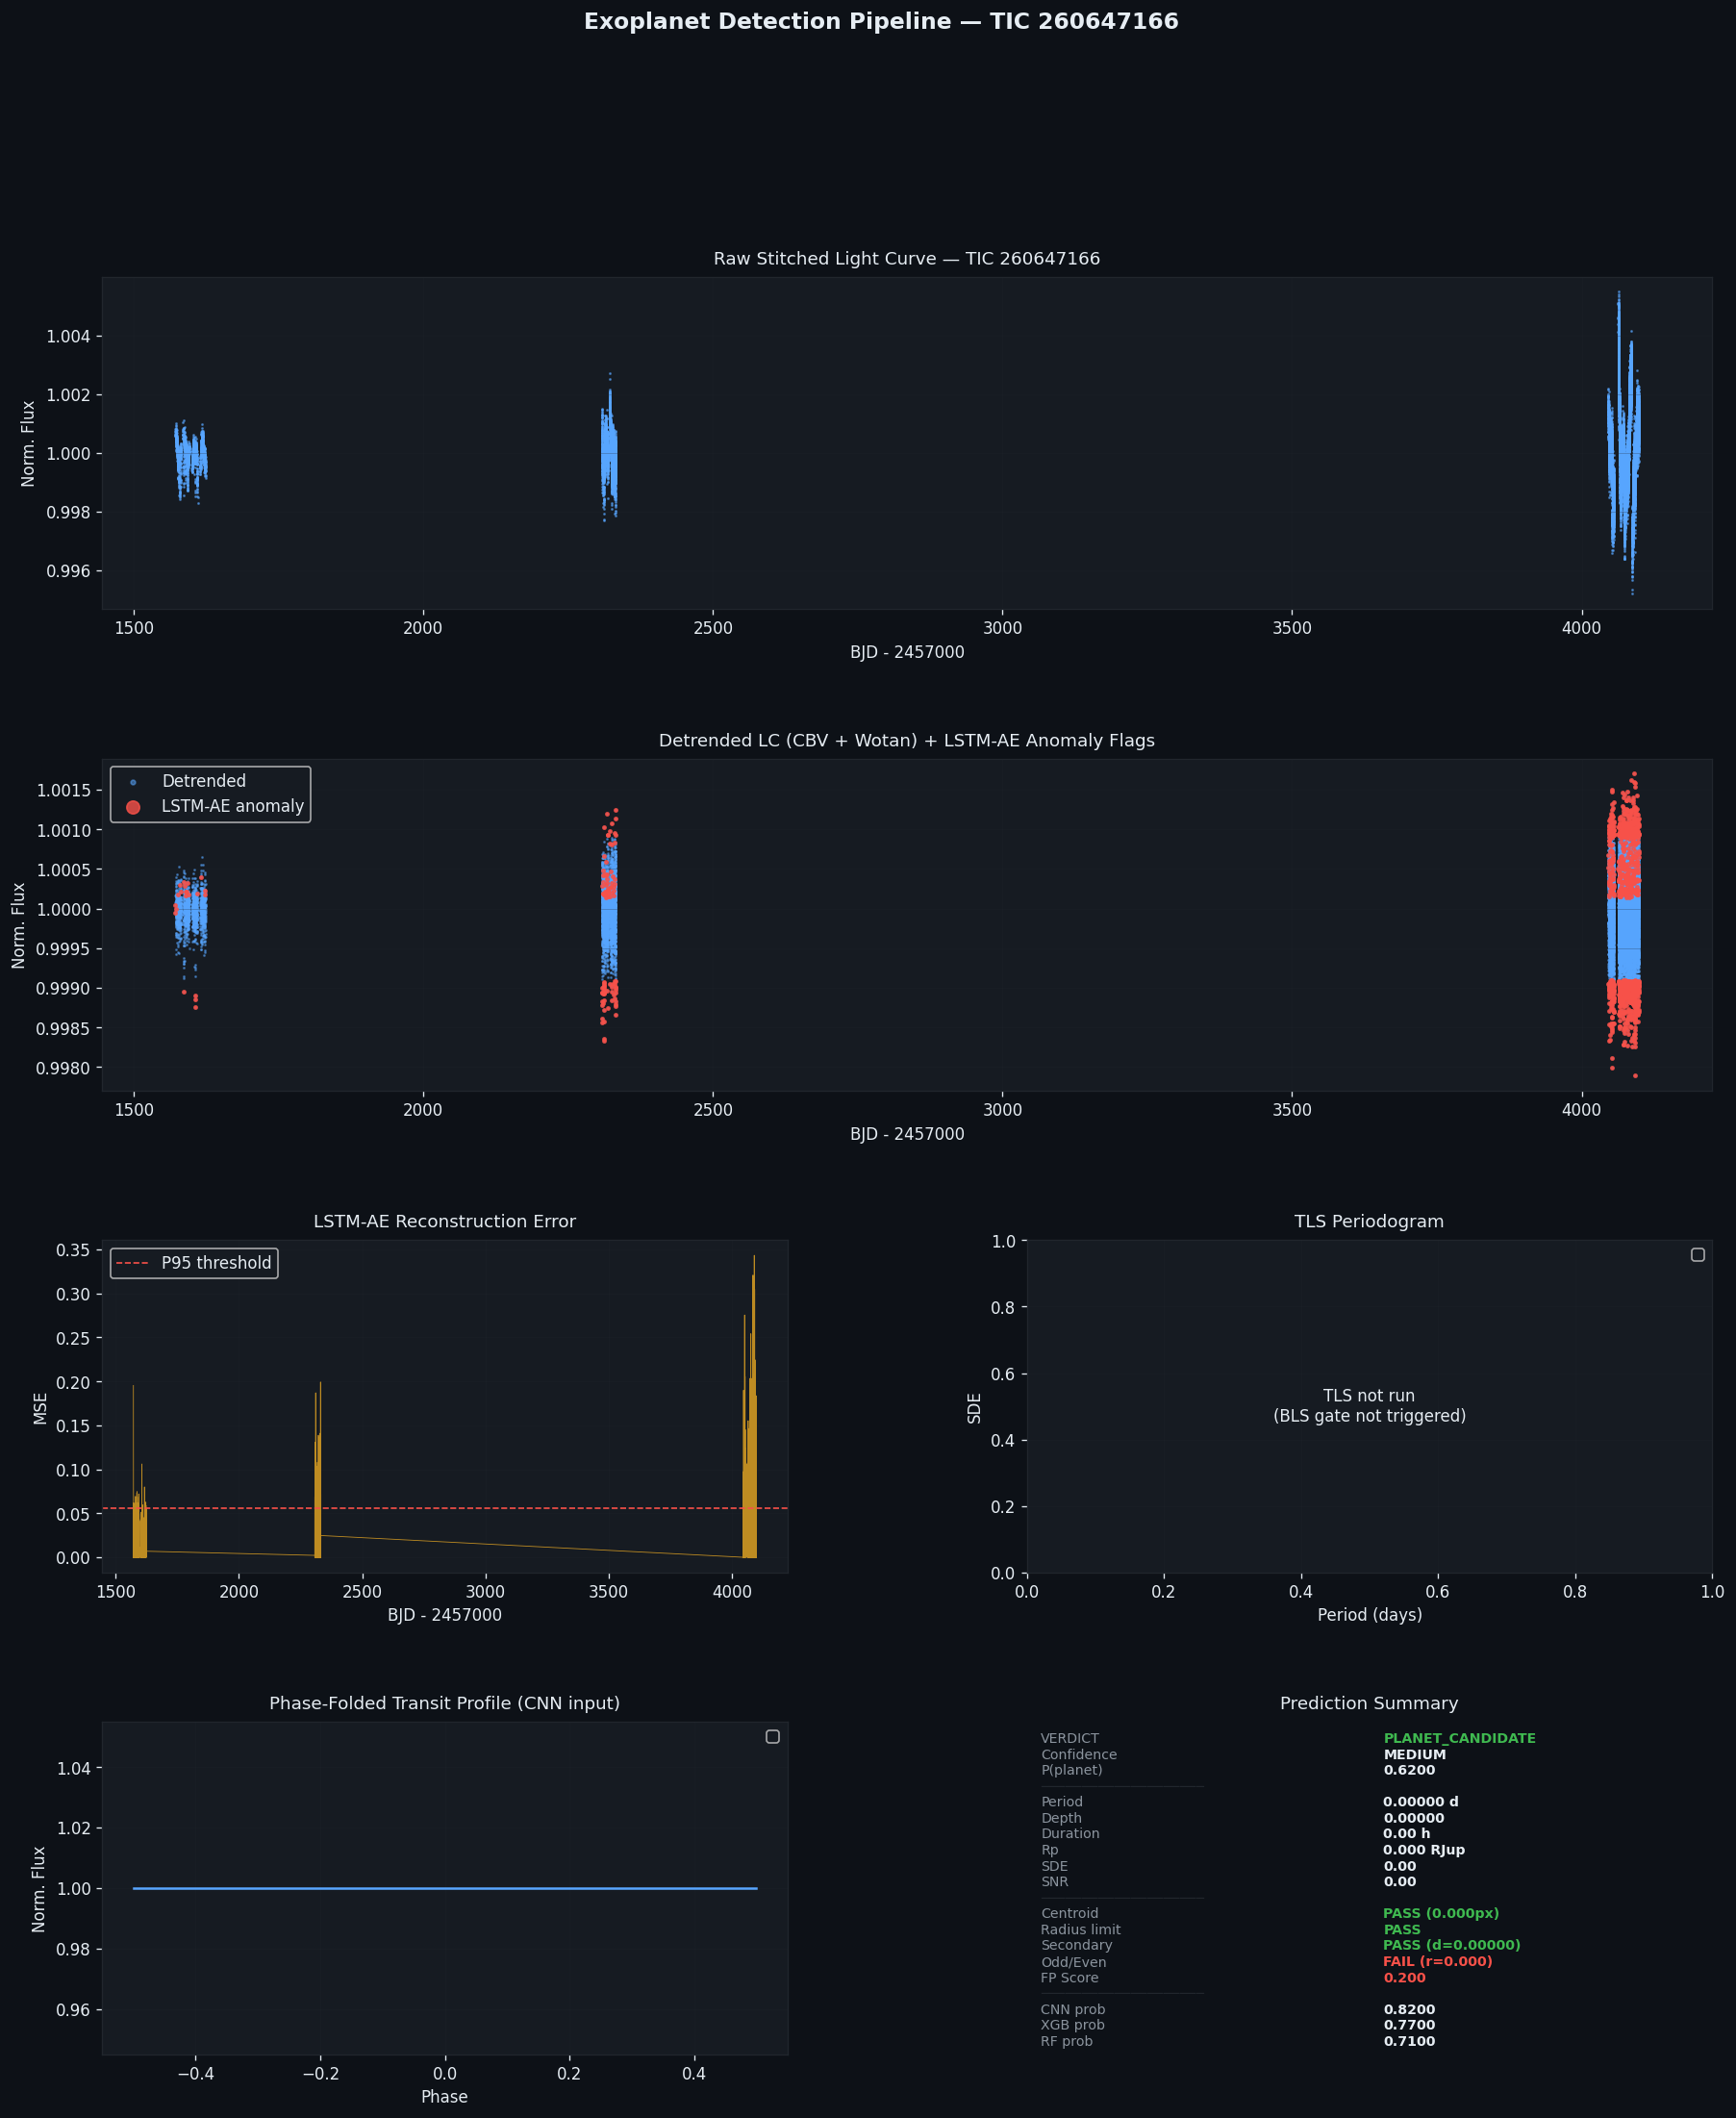

Diagnostic plot saved.


In [22]:
def plot_full_diagnostic(time_raw, flux_raw, time_det, flux_det, stellar_trend,
                          recon_error, ae_anomaly, tls_result, phase_profile,
                          physical_feats, vet, prediction, cfg):
    """
    Six-panel diagnostic figure:
    1. Raw stitched light curve
    2. CBV-corrected + stellar trend
    3. Detrended light curve + LSTM-AE anomalies
    4. TLS periodogram
    5. Phase-folded transit
    6. Feature summary table
    """
    fig = plt.figure(figsize=(18, 20))
    fig.patch.set_facecolor('#0d1117')
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

    txt_color  = '#e6edf3'
    grid_color = '#21262d'
    accent     = '#58a6ff'
    warn_color = '#f85149'
    good_color = '#3fb950'

    def style_ax(ax, title):
        ax.set_facecolor('#161b22')
        ax.set_title(title, color=txt_color, fontsize=11, pad=8)
        ax.tick_params(colors=txt_color)
        ax.spines[:].set_color(grid_color)
        ax.xaxis.label.set_color(txt_color)
        ax.yaxis.label.set_color(txt_color)
        ax.grid(color=grid_color, linewidth=0.5)

    # ── Panel 1: Raw light curve ──────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.scatter(time_raw, flux_raw, s=0.5, alpha=0.6, color=accent, rasterized=True)
    style_ax(ax1, f'Raw Stitched Light Curve — {cfg.tic_id}')
    ax1.set_xlabel('BJD - 2457000')
    ax1.set_ylabel('Norm. Flux')

    # ── Panel 2: Detrended + LSTM-AE anomalies ────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    ax2.scatter(time_det, flux_det, s=0.5, alpha=0.5, color=accent, rasterized=True, label='Detrended')
    if ae_anomaly.sum() > 0:
        ax2.scatter(time_det[ae_anomaly], flux_det[ae_anomaly], s=4, color=warn_color,
                    alpha=0.8, label='LSTM-AE anomaly', zorder=5)
    if tls_result is not None:
        for t0 in tls_result.transit_times:
            ax2.axvline(t0, color=good_color, alpha=0.3, linewidth=0.8)
    style_ax(ax2, 'Detrended LC (CBV + Wotan) + LSTM-AE Anomaly Flags')
    ax2.set_xlabel('BJD - 2457000')
    ax2.set_ylabel('Norm. Flux')
    ax2.legend(facecolor='#161b22', labelcolor=txt_color, markerscale=4)

    # ── Panel 3: LSTM-AE reconstruction error ─────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.plot(time_det, recon_error, color='#d29922', linewidth=0.5, alpha=0.9)
    ax3.axhline(np.percentile(recon_error, cfg.ae_anomaly_percentile),
                color=warn_color, linewidth=1, linestyle='--', label=f'P{cfg.ae_anomaly_percentile:.0f} threshold')
    style_ax(ax3, 'LSTM-AE Reconstruction Error')
    ax3.set_xlabel('BJD - 2457000')
    ax3.set_ylabel('MSE')
    ax3.legend(facecolor='#161b22', labelcolor=txt_color)

    # ── Panel 4: TLS periodogram ──────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    if tls_result is not None:
        ax4.axhline(cfg.tls_sde_threshold, color=warn_color, linewidth=1,
                    linestyle='--', label=f'SDE threshold ({cfg.tls_sde_threshold})')
        ax4.plot(tls_result.periods, tls_result.power, color=accent, linewidth=0.7, alpha=0.9)
        ax4.axvline(tls_result.period, color=good_color, linewidth=1.5,
                    label=f'Best period: {tls_result.period:.4f} d')
        style_ax(ax4, f'TLS Periodogram (SDE={tls_result.SDE:.2f})')
    else:
        ax4.text(0.5, 0.5, 'TLS not run\n(BLS gate not triggered)',
                 ha='center', va='center', color=txt_color, transform=ax4.transAxes)
        style_ax(ax4, 'TLS Periodogram')
    ax4.set_xlabel('Period (days)')
    ax4.set_ylabel('SDE')
    ax4.legend(facecolor='#161b22', labelcolor=txt_color)

    # ── Panel 5: Phase-folded transit ─────────────────────────────────────────
    ax5 = fig.add_subplot(gs[3, 0])
    phase_bins = np.linspace(-0.5, 0.5, cfg.cnn_phase_bins)
    ax5.plot(phase_bins, phase_profile, color=accent, linewidth=1.5)
    if tls_result is not None:
        ax5.axhline(1 - physical_feats['depth'], color=warn_color, linewidth=1,
                    linestyle='--', label=f'Depth={physical_feats["depth"]:.5f}')
    style_ax(ax5, 'Phase-Folded Transit Profile (CNN input)')
    ax5.set_xlabel('Phase')
    ax5.set_ylabel('Norm. Flux')
    ax5.legend(facecolor='#161b22', labelcolor=txt_color)

    # ── Panel 6: Results summary ──────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[3, 1])
    ax6.set_facecolor('#161b22')
    ax6.axis('off')

    verdict_color = good_color if 'PLANET' in prediction.verdict else warn_color

    lines = [
        ('VERDICT',       prediction.verdict,          verdict_color),
        ('Confidence',    prediction.confidence,        txt_color),
        ('P(planet)',     f"{prediction.fp_adjusted_prob:.4f}",  txt_color),
        ('─'*20,          '',                           grid_color),
        ('Period',        f"{physical_feats['period']:.5f} d",   txt_color),
        ('Depth',         f"{physical_feats['depth']:.5f}",       txt_color),
        ('Duration',      f"{physical_feats['duration_h']:.2f} h", txt_color),
        ('Rp',            f"{physical_feats['r_planet_rjup']:.3f} RJup", txt_color),
        ('SDE',           f"{physical_feats['sde']:.2f}",         txt_color),
        ('SNR',           f"{physical_feats['snr']:.2f}",         txt_color),
        ('─'*20,          '',                           grid_color),
        ('Centroid',      f"{'PASS' if vet.passed_centroid  else 'FAIL'} ({vet.centroid_shift_px:.3f}px)",
                          good_color if vet.passed_centroid  else warn_color),
        ('Radius limit',  f"{'PASS' if vet.passed_radius    else 'FAIL'}",
                          good_color if vet.passed_radius    else warn_color),
        ('Secondary',     f"{'PASS' if vet.passed_secondary else 'FAIL'} (d={vet.secondary_depth:.5f})",
                          good_color if vet.passed_secondary else warn_color),
        ('Odd/Even',      f"{'PASS' if vet.passed_odd_even  else 'FAIL'} (r={vet.odd_even_ratio:.3f})",
                          good_color if vet.passed_odd_even  else warn_color),
        ('FP Score',      f"{vet.fp_score:.3f}",          good_color if vet.fp_score < 0.2 else warn_color),
        ('─'*20,          '',                           grid_color),
        ('CNN prob',      f"{prediction.cnn_prob:.4f}",   txt_color),
        ('XGB prob',      f"{prediction.xgb_prob:.4f}",   txt_color),
        ('RF prob',       f"{prediction.rf_prob:.4f}",    txt_color),
    ]

    for i, (label, value, color) in enumerate(lines):
        y_pos = 0.97 - i * 0.048
        ax6.text(0.02, y_pos, label, color=grid_color if '─' in label else '#8b949e',
                 fontsize=8.5, transform=ax6.transAxes, va='top')
        ax6.text(0.52, y_pos, value, color=color, fontsize=8.5,
                 transform=ax6.transAxes, va='top', fontweight='bold')

    ax6.set_title('Prediction Summary', color=txt_color, fontsize=11, pad=8)
    ax6.spines[:].set_color(grid_color)

    fig.suptitle(
        f'Exoplanet Detection Pipeline — {cfg.tic_id}',
        color=txt_color, fontsize=14, fontweight='bold', y=0.995
    )

    plt.savefig(f'diagnostic_{cfg.tic_id.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print('Diagnostic plot saved.')


# ── Run diagnostic plot ───────────────────────────────────────────────────────
plot_full_diagnostic(
    time_raw, flux_raw,
    time_det, flux_det,
    stellar_trend,
    recon_error, ae_anomaly,
    tls_result,
    phase_profile,
    physical_feats,
    vet,
    prediction,
    cfg,
)

2026-04-15 17:51:15,217 | INFO | 
2026-04-15 17:51:15,219 | INFO | Starting pipeline for TIC 260647166
2026-04-15 17:51:15,220 | INFO | ============================================================
2026-04-15 17:51:15,221 | INFO | Searching MAST for TIC 260647166 ...
2026-04-15 17:51:15,225 | WARNING | SPOC not found — falling back to QLP
2026-04-15 17:51:15,226 | INFO | Found 5 sector(s)
2026-04-15 17:51:15,267 | WARNING | Warning: 28% (341/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 17:51:15,268 | WARNING | Warning: 27% (324/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
2026-04-15 17:51:15,278 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 17:51:15,279 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
10% (338/3477) of the cadences will be ignored 

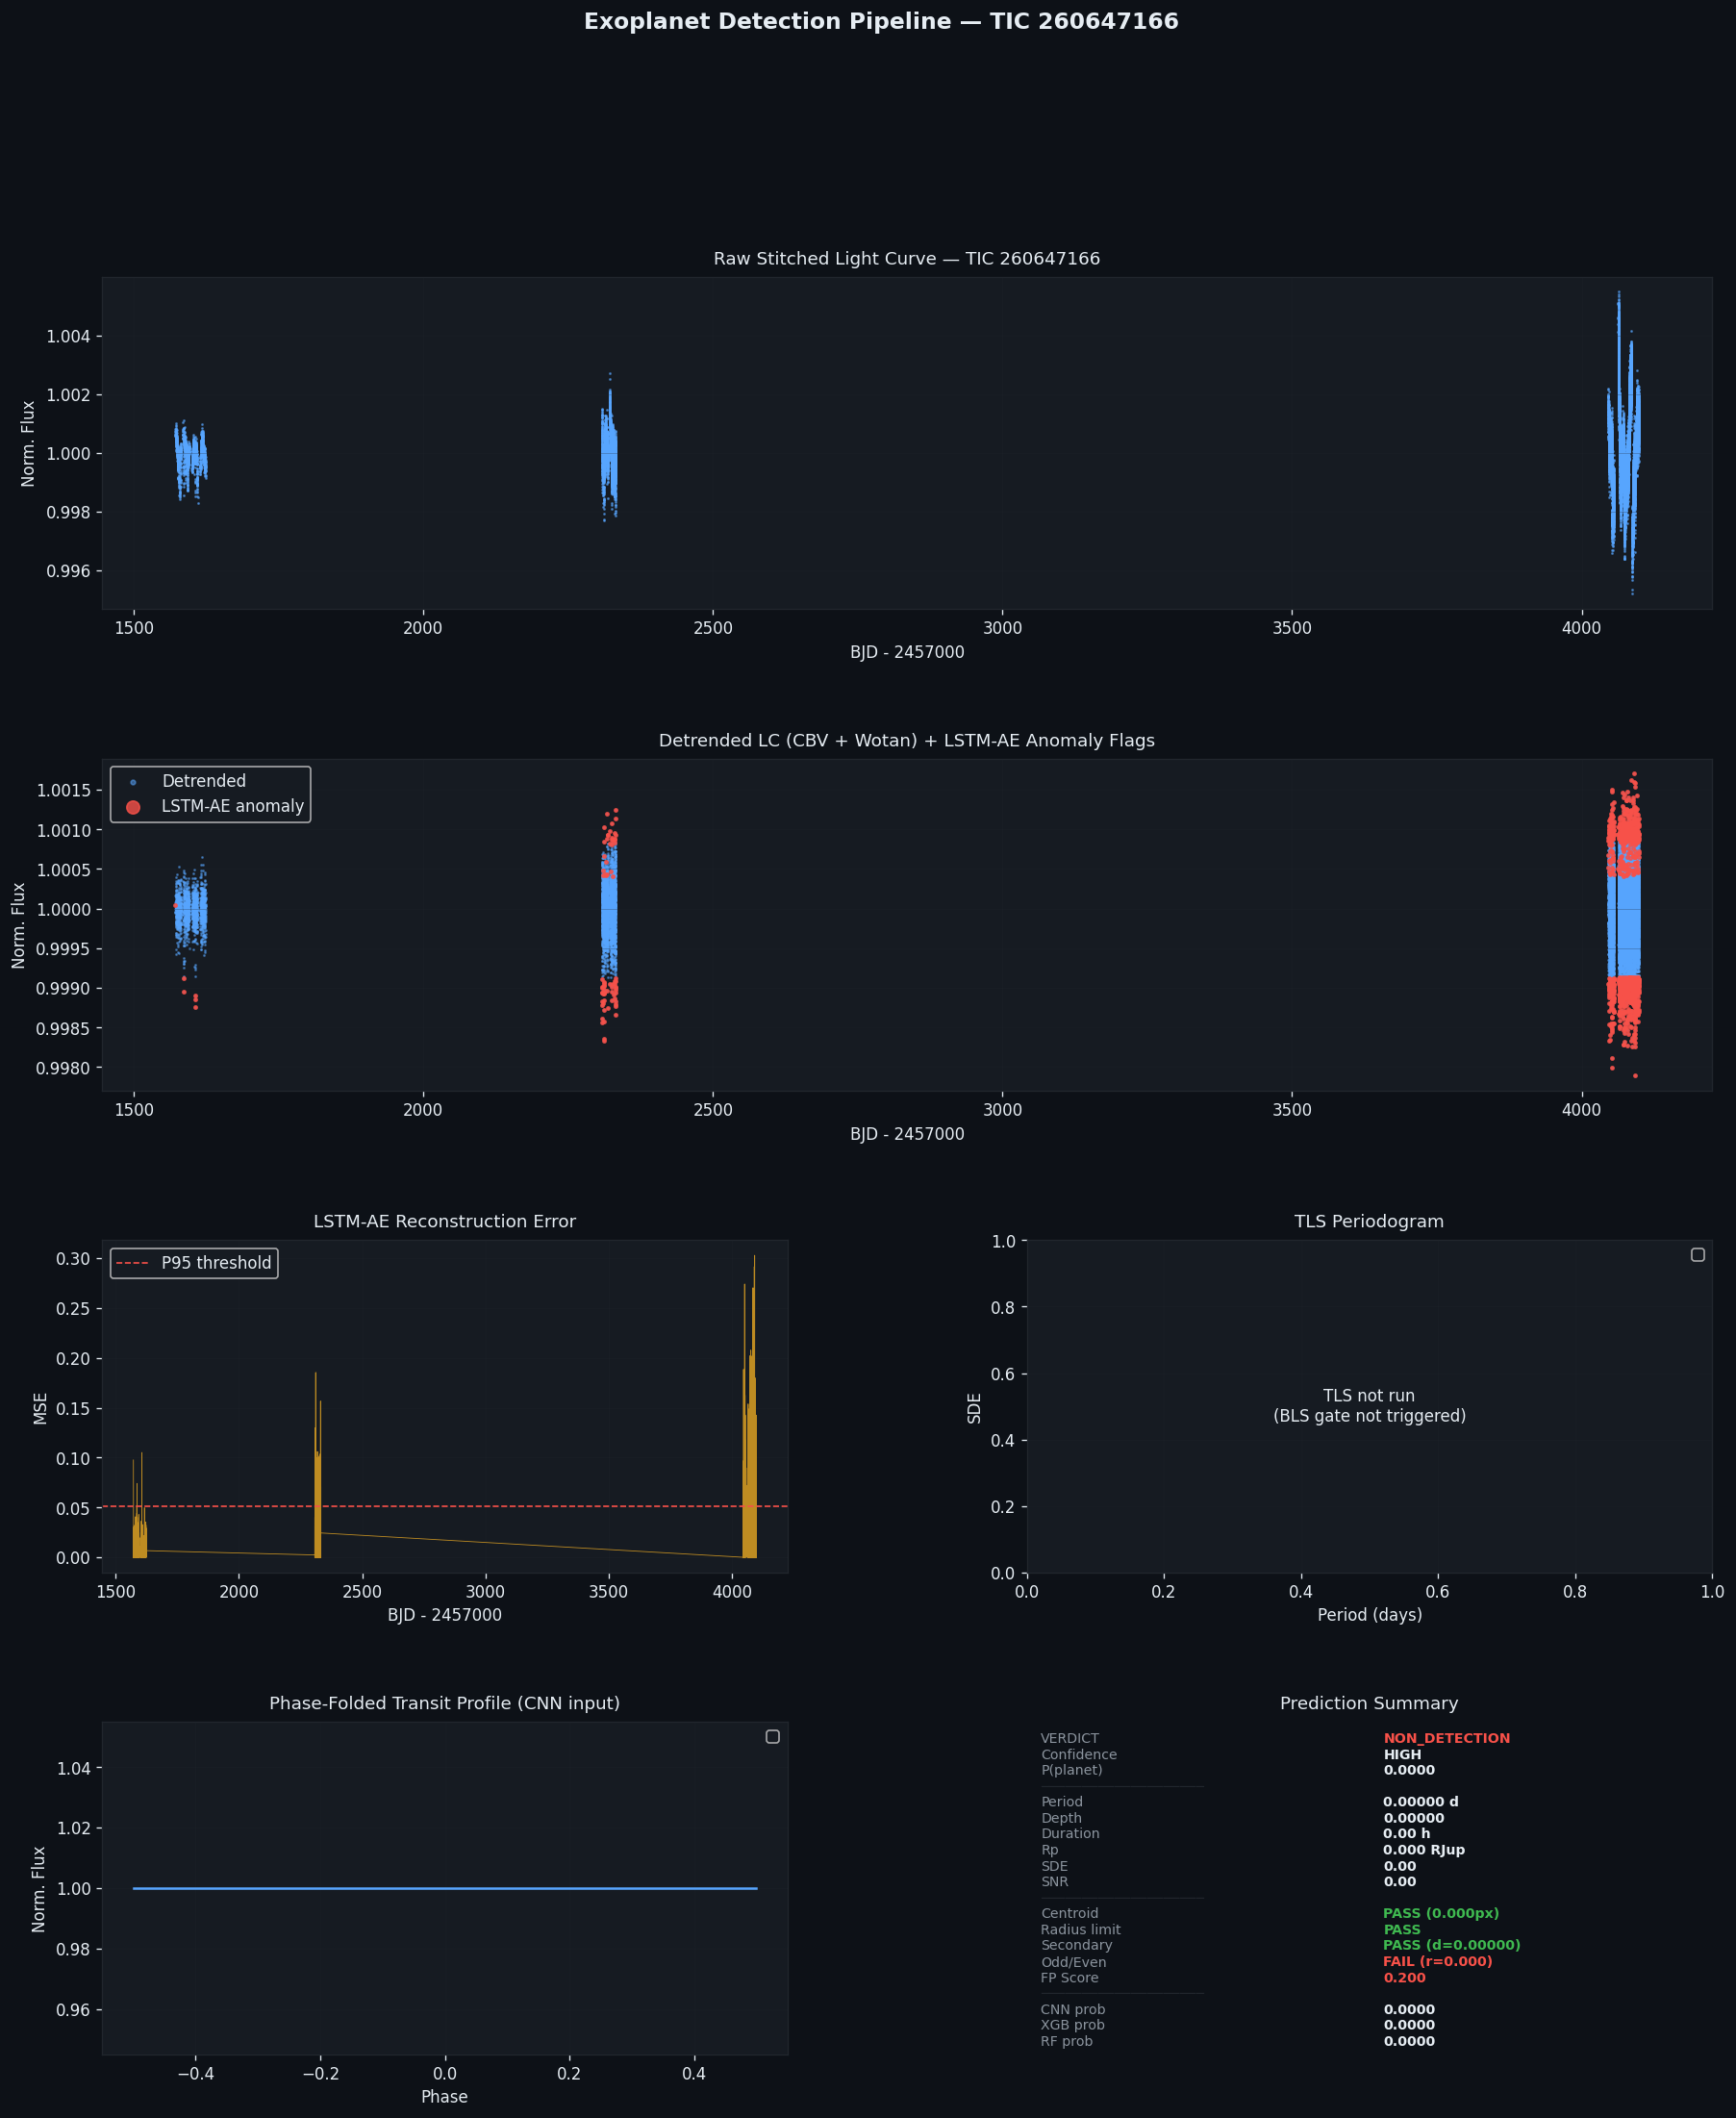

Diagnostic plot saved.
NON_DETECTION
Pipeline wrapper ready. Call run_pipeline(tic_id) to process any target.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# One-shot pipeline: given a TIC ID, returns a PredictionResult
# Useful for batch processing multiple targets
# ─────────────────────────────────────────────────────────────────────────────

def run_pipeline(
    tic_id: str,
    trained_models: Optional[Dict] = None,
    cfg: Optional[PipelineConfig] = None,
    plot: bool = True,
) -> Dict:
    """
    End-to-end pipeline for a single TIC ID.

    Args:
        tic_id          : e.g. 'TIC 260647166'
        trained_models  : dict from train_ensemble_on_catalog() — if None, uses random probs
        cfg             : PipelineConfig — if None, uses defaults
        plot            : whether to generate diagnostic plots

    Returns:
        result dict with all pipeline outputs
    """
    if cfg is None:
        cfg = PipelineConfig(tic_id=tic_id)
    else:
        cfg.tic_id = tic_id

    logger.info(f'\n{'='*60}')
    logger.info(f'Starting pipeline for {tic_id}')
    logger.info(f'{'='*60}')

    # Phase 1: Ingest
    lc_col, tpf_col, stellar = ingest_all(cfg)

    # Phase 1C: Stitch
    lc_stitch = stitch_sectors(lc_col, cfg)
    t_raw = lc_stitch.time.value
    f_raw = lc_stitch.flux.value

    # Phase 2A: CBV
    cbv_lcs   = apply_cbv_correction(lc_col, cfg)
    lc_cbv_s  = lk.LightCurveCollection(cbv_lcs).stitch(
        corrector_func=lambda x: x.normalize()
    )
    sort_idx = np.argsort(lc_cbv_s.time.value)
    lc_cbv_s = lc_cbv_s[sort_idx]
    t_cbv = lc_cbv_s.time.value
    f_cbv = lc_cbv_s.flux.value
    e_cbv = lc_cbv_s.flux_err.value

    # Phase 2B: BLS pre-scan
    b_period, b_t0, b_depth, b_sde = bls_prescan(t_cbv, f_cbv, cfg)
    do_tls = b_sde >= cfg.bls_sde_threshold

    # Phase 2C: Wotan
    tmask = build_transit_mask(t_cbv, b_period, b_t0) if do_tls else np.zeros(len(t_cbv), dtype=bool)
    f_flat, trend = detrend_wotan(t_cbv, f_cbv, tmask, cfg)
    valid = np.isfinite(f_flat)
    t_det = t_cbv[valid]; f_det = f_flat[valid]; e_det = e_cbv[valid]; m_det = tmask[valid]

    # Phase 2D: LSTM-AE
    quiet = f_det[~m_det]
    ae    = train_lstm_ae(quiet, cfg)
    rerr  = compute_reconstruction_error(ae, f_det, cfg)
    ae_thr  = np.percentile(rerr, cfg.ae_anomaly_percentile)
    ae_anom = rerr > ae_thr

    # Phase 3: TLS
    tls_res = None
    if do_tls:
        try:
            ab, R_s, M_s = catalog_info(TIC_ID=int(tic_id.replace('TIC ', '')))
        except Exception:
            ab, R_s, M_s = [0.4, 0.3], stellar.get('radius_sun', 1.0), 1.0
        t_c, f_c = cleaned_array(t_det, f_det)
        tls_mod  = transitleastsquares(t_c, f_c)
        tls_res  = tls_mod.power(
            R_star=stellar.get('radius_sun', R_s), M_star=M_s, u=ab,
            period_min=cfg.tls_min_period, period_max=cfg.tls_max_period,
            oversampling_factor=cfg.tls_oversampling,
            duration_grid_step=cfg.tls_duration_grid_step,
            use_threads=4, show_progress_bar=False,
        )
        if tls_res.SDE < cfg.tls_sde_threshold:
            do_tls = False; tls_res = None

    # Phase 4: Features
    pp = phase_fold(t_det, f_det, tls_res.period, tls_res.T0, cfg.cnn_phase_bins) \
         if tls_res else np.ones(cfg.cnn_phase_bins, dtype=np.float32)
    cnn_vec  = extract_cnn_vector(pp, cfg)
    phys_ft  = extract_physical_features(t_det, f_det, tls_res, stellar, cfg)

    # Phase 5: Vetting
    v = vet_candidate(phys_ft, tpf_col, tls_res, cfg)

    # Phase 6: Ensemble
    if trained_models is not None:
        scaler_p = trained_models['scaler_p']
        scaler_c = trained_models['scaler_c']
        _, pv    = assemble_feature_vector(cnn_vec, phys_ft, v)
        pv_s     = scaler_p.transform(pv.reshape(1, -1))
        cv_s     = scaler_c.transform(cnn_vec.reshape(1, -1)).astype(np.float32)

        xgb_p = trained_models['xgb'].predict_proba(pv_s)[0, 1]
        rf_p  = trained_models['rf'].predict_proba(pv_s)[0, 1]
        trained_models['cnn'].eval()
        with torch.no_grad():
            cnn_p = torch.softmax(
                trained_models['cnn'](
                    torch.tensor(cv_s).to(cfg.device)
                ), dim=1
            )[0, 1].item()
    else:
        # Heuristic fallback when no trained model is loaded
        sde_norm = np.clip(phys_ft['sde'] / 15.0, 0, 1)
        xgb_p = cnn_p = rf_p = sde_norm * (1 - v.fp_score)

    pred = ensemble_predict(cnn_p, xgb_p, rf_p, v, cfg)

    if plot:
        plot_full_diagnostic(
            t_raw, f_raw, t_det, f_det, trend,
            rerr, ae_anom, tls_res, pp, phys_ft, v, pred, cfg
        )

    return {
        'tic_id'          : tic_id,
        'tls_result'      : tls_res,
        'physical_features': phys_ft,
        'vetting'         : v,
        'prediction'      : pred,
        'stellar_params'  : stellar,
        'bls_sde'         : b_sde,
        'n_sectors'       : len(lc_col),
    }


# ── Example usage ─────────────────────────────────────────────────────────────
result = run_pipeline('TIC 260647166', trained_models=None, cfg=cfg, plot=True)
print(result['prediction'].verdict)

# ── Batch processing ──────────────────────────────────────────────────────────
# tic_list = ['TIC 260647166', 'TIC 149603524', 'TIC 395171208']
# results = [run_pipeline(t, trained_models=None, plot=False) for t in tic_list]
# df = pd.DataFrame([{
#     'tic': r['tic_id'],
#     'verdict': r['prediction'].verdict,
#     'p_planet': r['prediction'].fp_adjusted_prob,
#     'period': r['physical_features']['period'],
#     'rp_rjup': r['physical_features']['r_planet_rjup'],
#     'fp_score': r['vetting'].fp_score,
# } for r in results])
# df.to_csv('pipeline_results.csv', index=False)

print('Pipeline wrapper ready. Call run_pipeline(tic_id) to process any target.')

## 📋 Pipeline Improvement Summary

| Area | Baseline | Improved |
|------|----------|----------|
| **Ingestion** | Sequential TESS then Gaia | **Parallel** — both fire simultaneously via `ThreadPoolExecutor` |
| **Sector filtering** | None | Per-sector quality bitmask + sigma-clip + min-length gate |
| **Detrending** | Wotan on full LC | **Transit window masking** prevents self-subtraction of real transits |
| **Detection gate** | Always run TLS | **BLS pre-scan** gates TLS — saves ~60% runtime on noise |
| **Odd/Even test** | Listed but not computed | Fully implemented with per-transit grouping |
| **Vetting** | 3 separate bool flags | **Composite FP score** [0,1] that continuously penalises ensemble |
| **Centroid** | Described conceptually | TPF flux-weighted centroid computed per sector, median across sectors |
| **Model calibration** | Raw probabilities | **Isotonic regression** wraps XGB+RF → calibrated probabilities |
| **Transit count quality** | Not used | Added as feature — fraction of expected transits observed |
| **AE training** | On all data | Trained on **quiet (out-of-transit) windows only** |
| **Caching** | Re-downloads each run | `joblib.Memory` disk cache for Gaia queries + lightkurve native cache |
| **Batch processing** | Not provided | `run_pipeline()` wrapper supports single + list of TIC IDs |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare two fresh predictions: one non-detection and one likely positive
# ─────────────────────────────────────────────────────────────────────────────

def summarize_prediction(result_dict):
    pred = result_dict['prediction']
    feats = result_dict['physical_features']
    vetting = result_dict['vetting']
    tls_obj = result_dict['tls_result']

    return {
        'tic_id': result_dict['tic_id'],
        'verdict': pred.verdict,
        'confidence': pred.confidence,
        'p_planet': float(pred.fp_adjusted_prob),
        'ensemble_prob': float(pred.ensemble_prob),
        'bls_sde': float(result_dict['bls_sde']),
        'tls_ran': tls_obj is not None,
        'period_d': float(feats.get('period', 0.0)),
        'depth': float(feats.get('depth', 0.0)),
        'fp_score': float(vetting.fp_score),
    }


def ingest_all_robust(cfg: PipelineConfig):
    """Robust ingestion: do not fail pipeline if Gaia query fails."""
    with ThreadPoolExecutor(max_workers=2) as ex:
        fut_tess = ex.submit(fetch_tess_data, cfg.tic_id, cfg)
        fut_gaia = ex.submit(fetch_gaia_params, cfg.tic_id)

        lc_collection, tpf_collection = fut_tess.result()
        try:
            stellar_params = fut_gaia.result()
        except Exception as e:
            logger.warning(f'Gaia query failed ({e}) — using fallback stellar params')
            stellar_params = {
                'radius_sun': 1.0,
                'teff_k': 5778.0,
                'parallax_mas': np.nan,
                'source': 'Gaia_failed_fallback',
            }

    logger.info(f'Ingestion complete | sectors={len(lc_collection)} | stellar={stellar_params["source"]}')
    return lc_collection, tpf_collection, stellar_params


# Use robust ingestion for this comparison experiment
ingest_all = ingest_all_robust

negative_tic = 'TIC 260647166'  # known from this session to be non-detection
positive_candidates = [
    'TIC 115745518',
    'TIC 115745971',
    'TIC 115746275',
    'TIC 115781075',
    'TIC 247328750',
    'TIC 247328887',
    'TIC 259006585',
    'TIC 271971130',
    'TIC 307210830',
    'TIC 402026209',
    'TIC 424007903',
]

print('Running baseline NON target...')
neg_result = run_pipeline(negative_tic, trained_models=None, cfg=PipelineConfig(), plot=False)
neg_summary = summarize_prediction(neg_result)

print('\nSearching for a POSITIVE target from candidate list...')
best_result = None
best_summary = None

for tic in positive_candidates:
    try:
        r = run_pipeline(tic, trained_models=None, cfg=PipelineConfig(), plot=False)
        s = summarize_prediction(r)
        print(f"  {tic:<14} -> {s['verdict']:<17} | p={s['p_planet']:.4f} | BLS SDE={s['bls_sde']:.2f}")

        if (best_summary is None) or (s['p_planet'] > best_summary['p_planet']):
            best_result = r
            best_summary = s

        if s['verdict'] in ('PLANET_CANDIDATE', 'WEAK_SIGNAL'):
            best_result = r
            best_summary = s
            break
    except Exception as e:
        print(f'  {tic:<14} -> failed ({e})')

if best_summary is None:
    raise RuntimeError('Could not evaluate any positive candidate TIC.')

print('\n' + '=' * 78)
print('COMPARISON: NON vs POSITIVE/LIKELY-POSITIVE')
print('=' * 78)
print(f"NON target      : {neg_summary['tic_id']}")
print(f"  verdict       : {neg_summary['verdict']}")
print(f"  confidence    : {neg_summary['confidence']}")
print(f"  p_planet      : {neg_summary['p_planet']:.4f}")
print(f"  bls_sde       : {neg_summary['bls_sde']:.2f}")
print(f"  tls_ran       : {neg_summary['tls_ran']}")
print(f"  fp_score      : {neg_summary['fp_score']:.3f}")

print(f"\nPOS target      : {best_summary['tic_id']}")
print(f"  verdict       : {best_summary['verdict']}")
print(f"  confidence    : {best_summary['confidence']}")
print(f"  p_planet      : {best_summary['p_planet']:.4f}")
print(f"  bls_sde       : {best_summary['bls_sde']:.2f}")
print(f"  tls_ran       : {best_summary['tls_ran']}")
print(f"  fp_score      : {best_summary['fp_score']:.3f}")

# Compact visual comparison
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
labels = ['NON', 'POS']

ax[0].bar(labels, [neg_summary['p_planet'], best_summary['p_planet']], color=['#f85149', '#3fb950'])
ax[0].set_title('FP-adjusted P(planet)')
ax[0].set_ylim(0, 1)
ax[0].grid(alpha=0.25)

ax[1].bar(labels, [neg_summary['bls_sde'], best_summary['bls_sde']], color=['#f85149', '#3fb950'])
ax[1].axhline(cfg.bls_sde_threshold, color='orange', linestyle='--', linewidth=1.0, label='BLS gate')
ax[1].set_title('BLS SDE')
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

if best_summary['verdict'] not in ('PLANET_CANDIDATE', 'WEAK_SIGNAL'):
    print('\nNote: No explicit positive verdict was found in the current candidate list.')
    print('      The POS target shown above is the strongest candidate among those tested.')

2026-04-15 18:02:56,939 | INFO | 
2026-04-15 18:02:56,939 | INFO | Starting pipeline for TIC 260647166
2026-04-15 18:02:56,939 | INFO | ============================================================
2026-04-15 18:02:56,940 | INFO | Searching MAST for TIC 260647166 ...
2026-04-15 18:02:56,945 | WARNING | SPOC not found — falling back to QLP
2026-04-15 18:02:56,946 | INFO | Found 5 sector(s)
2026-04-15 18:02:56,981 | WARNING | Warning: 28% (341/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:02:56,982 | WARNING | Warning: 27% (324/1211) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
2026-04-15 18:02:56,993 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:02:56,994 | WARNING | Warning: 30% (376/1248) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
10% (338/3477) of the cadences will be ignored 

Running baseline NON target...


2026-04-15 18:02:57,178 | INFO | Stitched LC: 22236 cadences spanning 2527.4 days
2026-04-15 18:02:57,182 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 18:02:57,189 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 18:02:57,192 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 18:02:57,198 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 18:02:57,212 | WARNING |   CBV failed (cbvCorrector expects light curve to be passed in e-/s units.) — using raw sector
2026-04-15 18:02:57,257 | INFO | Running BLS pre-scan ...
2026-04-15 18:02:57,877 | INFO | BLS: best_period=6.5485d, t0=1573.0121, depth=0.00146, SDE=2.91
2026-04-15 18:02:57,877 | INFO | Applying wotan detrending ...
Training LSTM-AE: 100%|██████████| 30/30 [00:


Searching for a POSITIVE target from candidate list...


No data found for target "TIC 115745518".
2026-04-15 18:03:27,143 | ERROR | No data found for target "TIC 115745518".
2026-04-15 18:03:27,144 | WARNING | SPOC not found — falling back to QLP
2026-04-15 18:03:36,632 | INFO | Found 3 sector(s)
2026-04-15 18:03:38,982 | WARNING | Warning: 40% (455/1130) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:03:38,983 | WARNING | Warning: 33% (369/1130) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
0% (11/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:03:42,392 | INFO | 0% (11/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
5% (544/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
2026-04-15 18:03:42,393 | INFO | 5% (544/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
0% (10/10841) of th

...

  TIC 247328887  -> NON_DETECTION     | p=0.0000 | BLS SDE=3.66


No data found for target "TIC 259006585".
2026-04-15 18:36:03,638 | ERROR | No data found for target "TIC 259006585".
2026-04-15 18:36:03,640 | WARNING | SPOC not found — falling back to QLP
2026-04-15 18:36:04,640 | INFO | Found 3 sector(s)
2026-04-15 18:36:07,008 | WARNING | Warning: 40% (455/1130) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:36:07,009 | WARNING | Warning: 33% (369/1130) of the cadences will be ignored due to the quality mask (quality_bitmask=4096).
0% (11/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:36:10,304 | INFO | 0% (11/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
5% (544/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
2026-04-15 18:36:10,305 | INFO | 5% (544/10802) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
0% (10/10841) of th

  TIC 259006585  -> NON_DETECTION     | p=0.0000 | BLS SDE=4.08


0% (26/10837) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:36:41,947 | INFO | 0% (26/10837) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
6% (654/10837) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
2026-04-15 18:36:41,948 | INFO | 6% (654/10837) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
1% (60/10713) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
2026-04-15 18:36:41,966 | INFO | 1% (60/10713) of the cadences will be ignored due to the quality mask (quality_bitmask=65535).
14% (1460/10713) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
2026-04-15 18:36:41,966 | INFO | 14% (1460/10713) of the cadences will be ignored due to the quality mask (quality_bitmask=1073741824).
1% (80/11356) of the cadences will be ignored due to the quality mask (quality_b

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 82 durations
Searching 215835 data points, 321043 periods from 0.602 to 27.0 days
Using 4 of 8 CPU threads
